In [2]:
"""
Bank renege example

Covers:
£
- Condition events

Scenario:
  A counter with a random service time and customers who renege. Based on the
  program bank08.py from TheBank tutorial of SimPy 2. (KGM)

"""
import random

import simpy


RANDOM_SEED = 42
NEW_CUSTOMERS = 500  # Total number of customers
INTERVAL_CUSTOMERS = 10.0  # Generate new customers roughly every x seconds
MIN_PATIENCE = 1  # Min. customer patience
MAX_PATIENCE = 3  # Max. customer patience


def source(env, number, interval, counter):
    """Source generates customers randomly"""
    for i in range(number):
        c = customer(env, 'Customer%02d' % i, counter, time_in_bank=12.0)
        env.process(c)
        t = random.expovariate(1.0 / interval)
        yield env.timeout(t)


def customer(env, name, counter, time_in_bank):
    """Customer arrives, is served and leaves."""
    arrive = env.now
    print('%7.4f %s: Here I am' % (arrive, name))

    with counter.request() as req:
        patience = random.uniform(MIN_PATIENCE, MAX_PATIENCE)
        # Wait for the counter or abort at the end of our tether
        results = yield req | env.timeout(patience)

        wait = env.now - arrive

        if req in results:
            # We got to the counter
            print('%7.4f %s: Waited %6.3f' % (env.now, name, wait))

            tib = random.expovariate(1.0 / time_in_bank)
            yield env.timeout(tib)
            print('%7.4f %s: Finished' % (env.now, name))

        else:
            # We reneged
            print('%7.4f %s: RENEGED after %6.3f' % (env.now, name, wait))




In [3]:

# Setup and start the simulation
print('Bank renege')
random.seed(RANDOM_SEED)
env = simpy.Environment()

# Start processes and run
counter = simpy.Resource(env, capacity=1)
env.process(source(env, NEW_CUSTOMERS, INTERVAL_CUSTOMERS, counter))
env.run()

Bank renege
 0.0000 Customer00: Here I am
 0.0000 Customer00: Waited  0.000
 3.8595 Customer00: Finished
10.2006 Customer01: Here I am
10.2006 Customer01: Waited  0.000
12.7265 Customer02: Here I am
13.9003 Customer02: RENEGED after  1.174
23.7507 Customer01: Finished
34.9993 Customer03: Here I am
34.9993 Customer03: Waited  0.000
37.9599 Customer03: Finished
40.4798 Customer04: Here I am
40.4798 Customer04: Waited  0.000
43.1401 Customer04: Finished
47.5190 Customer05: Here I am
47.5190 Customer05: Waited  0.000
50.5073 Customer05: Finished
58.0139 Customer06: Here I am
58.0139 Customer06: Waited  0.000
58.0921 Customer06: Finished
66.9120 Customer07: Here I am
66.9120 Customer07: Waited  0.000
71.9027 Customer07: Finished
83.3016 Customer08: Here I am
83.3016 Customer08: Waited  0.000
84.9915 Customer09: Here I am
85.9648 Customer10: Here I am
86.1849 Customer09: RENEGED after  1.193
88.1723 Customer10: RENEGED after  2.207
88.2261 Customer08: Finished
104.7704 Customer11: Here I am


With visualization


--- Simulation Results ---
Total customers served: 50
Average waiting time: 29.75
Max waiting time: 60.51
Min waiting time: 0.00

Counter 1 usage:
  Total service time: 99.23
  Average service time: 5.22
  Number of customers served: 19
  Utilization: 112.90%

Counter 2 usage:
  Total service time: 87.93
  Average service time: 5.17
  Number of customers served: 17
  Utilization: 100.04%

Counter 3 usage:
  Total service time: 69.91
  Average service time: 4.99
  Number of customers served: 14
  Utilization: 79.55%


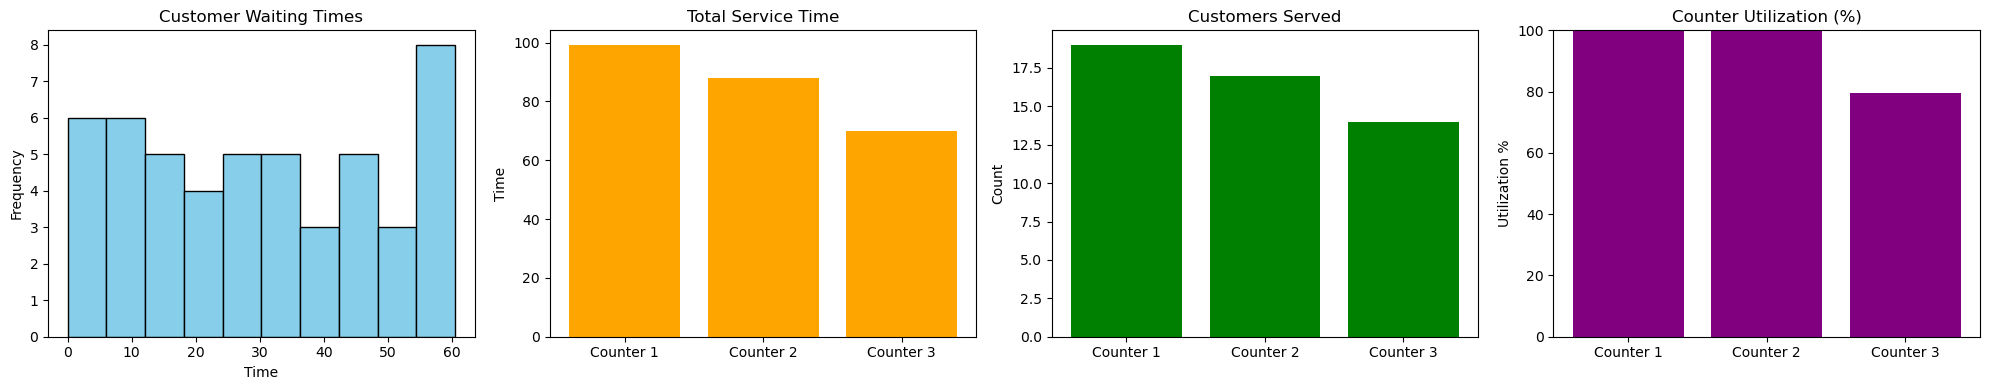

In [7]:
import simpy
import random
import statistics
import matplotlib.pyplot as plt

# Simulation parameters
RANDOM_SEED = 42
NUM_CUSTOMERS = 50
NUM_COUNTERS = 3  # Change this to set number of counters
INTER_ARRIVAL_TIME = 0.5
SERVICE_TIME = (3, 7)

# Tracking stats
wait_times = []
counter_usage = {i: [] for i in range(NUM_COUNTERS)}

def customer(env, name, counters):
    arrival_time = env.now
    with counters.request() as request:
        yield request
        wait = env.now - arrival_time
        wait_times.append(wait)

        service_duration = random.uniform(*SERVICE_TIME)
        # Randomly assign a counter ID (since SimPy doesn't track individual units)
        counter_id = random.randint(0, NUM_COUNTERS - 1)
        counter_usage[counter_id].append(service_duration)

        yield env.timeout(service_duration)

def customer_generator(env, counters):
    for i in range(NUM_CUSTOMERS):
        yield env.timeout(random.expovariate(1.0 / INTER_ARRIVAL_TIME))
        env.process(customer(env, f"Customer {i+1}", counters))

# Setup and run simulation
random.seed(RANDOM_SEED)
env = simpy.Environment()
counters = simpy.Resource(env, capacity=NUM_COUNTERS)
env.process(customer_generator(env, counters))
env.run()

# Simulation time
simulation_time = env.now

# Print statistics
print("\n--- Simulation Results ---")
print(f"Total customers served: {NUM_CUSTOMERS}")
print(f"Average waiting time: {statistics.mean(wait_times):.2f}")
print(f"Max waiting time: {max(wait_times):.2f}")
print(f"Min waiting time: {min(wait_times):.2f}")

utilization = {}
for i in range(NUM_COUNTERS):
    usage = counter_usage[i]
    total_service = sum(usage)
    utilization[i] = (total_service / simulation_time) * 100
    print(f"\nCounter {i+1} usage:")
    print(f"  Total service time: {total_service:.2f}")
    print(f"  Average service time: {statistics.mean(usage):.2f}" if usage else "  No customers served")
    print(f"  Number of customers served: {len(usage)}")
    print(f"  Utilization: {utilization[i]:.2f}%")

# Visualization
fig, axs = plt.subplots(1, 4, figsize=(20, 4))

# Histogram of waiting times
axs[0].hist(wait_times, bins=10, color='skyblue', edgecolor='black')
axs[0].set_title('Customer Waiting Times')
axs[0].set_xlabel('Time')
axs[0].set_ylabel('Frequency')

# Total service time per counter
axs[1].bar([f'Counter {i+1}' for i in range(NUM_COUNTERS)],
           [sum(counter_usage[i]) for i in range(NUM_COUNTERS)],
           color='orange')
axs[1].set_title('Total Service Time')
axs[1].set_ylabel('Time')

# Number of customers served per counter
axs[2].bar([f'Counter {i+1}' for i in range(NUM_COUNTERS)],
           [len(counter_usage[i]) for i in range(NUM_COUNTERS)],
           color='green')
axs[2].set_title('Customers Served')
axs[2].set_ylabel('Count')

# Utilization per counter
axs[3].bar([f'Counter {i+1}' for i in range(NUM_COUNTERS)],
           [utilization[i] for i in range(NUM_COUNTERS)],
           color='purple')
axs[3].set_title('Counter Utilization (%)')
axs[3].set_ylabel('Utilization %')
axs[3].set_ylim(0, 100)

plt.tight_layout()
plt.show()